# Realised-state shared cache demo (PR14)

This notebook demonstrates cross-experiment societal-access reuse with a transactional shared cache and reports reuse/performance telemetry.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import time
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from ema_workbench import SequentialEvaluator, MultiprocessingEvaluator, Samplers
from src.caching import load_simulation_caches
from src.adaptation import simulate_asset_damage_recovery_access_breakdown_ema
from src.societal_access import list_societal_metric_names
from config import get_config, get_development_config, setup_dev_directories, get_simulation_params
from src.impacts import create_voronoi_for_asset_type, prepare_population_impact_data, prepare_land_use_impact_data, update_voll_rates, prepare_land_use_impact_data

from src.data_loader import load_hazard_maps, load_electricity_assets
from src.caching import load_simulation_caches, save_simulation_caches

from src.island_analysis import compute_island_geodataframe_from_graph
from src.societal_access import (
    build_origin_island_allocations,
    apply_population_to_allocations,
    get_or_build_allocation,
    list_societal_metric_names,
)


config = get_development_config()
caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])
shared_db = config['interim_dir'] / 'societal_realized_state_cache.sqlite'

cache_telemetry = {}
USE_SHARED_REALIZED_STATE_CACHE = True  # set to False to use local caches / only single runs or sequential evaluator
shared_cache_cfg = {
    'enabled': USE_SHARED_REALIZED_STATE_CACHE,
    'backend': 'sqlite',
    'path': str(shared_db),
    'namespace': 'use_case_sample_societal_access',
    'schema_version': '1.0.0',
    'timeout_seconds': 30.0,
    'busy_timeout_ms': 30000,
    'max_retries': 5,
    'retry_backoff_seconds': 0.05,
}


c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\ema_workbench\em_framework\__init__.py:101: UserWarning: ipyparallel not installed - IpyparalleEvaluator not available
  warnings.warn("ipyparallel not installed - IpyparalleEvaluator not available")


Loading simulation caches...
No accessibility cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\accessibility_cache_test_hazard_timesteps.pkl
No hazard extraction cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\hazard_extraction_cache_test_hazard_timesteps.pkl
No island cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\island_cache_test_hazard_timesteps.pkl
No societal allocation cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\societal_allocation_cache_test_hazard_timesteps.pkl


In [2]:
# Set up configuration
config = get_development_config() #get_config() gets parameters directly from config.py in root, development config uses sample data
# config = get_config()
setup_dev_directories(config, remove_cache=True) # For a clean run, set remove_cache=True to clear all caches and start fresh
HAZARD_EXTRACTION_METHOD = config['analysis_config']['hazard_extraction_method']

# Configure simulation parameters from config
simulation_params = get_simulation_params(config) 
accessibility_model = None
simulation_params['accessibility_model'] = accessibility_model

print(f"\nSimulation configuration:")
for key, value in simulation_params.items():
    if key != 'config':  # Don't print the entire config
        print(f"  {key}: {value}")

print(f"\nDirectory structure:")
print(f"  Interim: {config['interim_dir']}")
print(f"  Output: {config['output_dir']}")
print(f"  Cache will be organized by hazard directory: {Path(config['hazard_dir']).name}")

# 6 for full data, 24 for sample data (which has 24 timesteps per day instead of 4)
config['simulation_config']['major_timestep'] = 24
# config['simulation_config']['major_timestep'] = 6
config['simulation_config']['verbose'] = False
max_days = None

caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])
print(f"Loaded caches: {[k for k in caches.keys() if caches[k] is not None]}")

root_dir = Path(config['root_dir'])
study_area_path = root_dir / 'data' / 'utilities' / 'stedin_area.geojson'
land_use_path = root_dir / 'data' / 'land_use' / 'CBS_Publicatiebestand_BBG2017_v1_sample.gpkg'
# land_use_path = root_dir / 'data' / 'land_use' / 'CBS_Publicatiebestand_BBG2017_v1.gpkg'
population_data_path = root_dir / "data" / "population" / "cbs_vk100_2024_v1_sample.gpkg"
# population_data_path = root_dir / "data" / "population" / "cbs_vk100_2024_v1.gpkg"

print(f"WARNING! Values of lost load should be calculated with country-wide VOLL rates, not sample data!")

# Cache path for asset_to_lu (the complete pre-computed lookup)
asset_to_lu_cache_path = config['interim_dir'] / f"{land_use_path.stem}_asset_to_lu.pkl"

Created directories: c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps, c:\repos\powerpath\powerpath\data\output\output_test_hazard_timesteps

Simulation configuration:
  flood_threshold: 0.2
  number_repair_crews: 5
  repair_crew_assignment_method: islands
  verbose: True
  recovery_parameters: {'repair_time_coefficients': [702.72, 3.14, 1.9891], 'damage_ratio_coefficients': (0.0468, 0.0077), 'fragility_models': {}, 'damage_threshold': 0.01, 'repair_threshold': 2.0}
  accessibility_model: None

Directory structure:
  Interim: c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps
  Output: c:\repos\powerpath\powerpath\data\output\output_test_hazard_timesteps
  Cache will be organized by hazard directory: test_hazard_timesteps
Loading simulation caches...
No accessibility cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\accessibility_cache_test_hazard_timesteps.pkl
No hazard extraction cache found at c:\repos\

Found 1 electricity station files matching types ['msls']
All .shp files in directory: ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Files with 'station': ['ls_stations_test_samples.shp', 'msls_stations_test_samples.shp', 'ms_stations_test_samples.shp']
Final matched files: ['msls_stations_test_samples.shp']
Loading electricity assets from msls_stations_test_samples.shp
Loaded 245 msls assets
Combined total: 245 electricity assets
Asset types: {'msls': 245}


C:\Users\peregrin\AppData\Local\Temp\ipykernel_12176\3915728599.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  assets_focus = gpd.GeoDataFrame(geometry=[assets_3857.unary_union.convex_hull.buffer(2000)], crs='EPSG:3857')


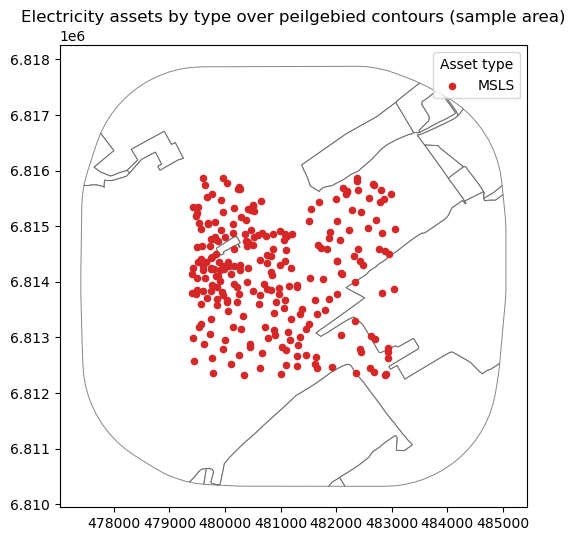

In [3]:
gdf_assets = load_electricity_assets(config['electricity_dir'], asset_types=['msls'])
                                    #  asset_types=['ls', 'ms', 'msls'])

# Plot assets on peilgebied contour subset (no web basemap)
fig, ax = plt.subplots(figsize=(8, 6))

assets_3857 = gdf_assets.to_crs('EPSG:3857')
peilgebied_3857 = gpd.read_file(root_dir / 'data' / 'utilities' / 'Peilgebieden_3857.shp').to_crs('EPSG:3857')
assets_focus = gpd.GeoDataFrame(geometry=[assets_3857.unary_union.convex_hull.buffer(2000)], crs='EPSG:3857')
peilgebied_focus = gpd.clip(peilgebied_3857, assets_focus)
if peilgebied_focus.empty:
    peilgebied_focus = peilgebied_3857

peilgebied_focus.boundary.plot(ax=ax, color='dimgray', linewidth=0.7, alpha=0.8, zorder=1)

asset_colors = {'ls': '#2ca02c', 'ms': '#1f77b4', 'msls': '#d62728'}
for atype, color in asset_colors.items():
    subset = assets_3857[assets_3857['type'] == atype]
    if not subset.empty:
        subset.centroid.plot(ax=ax, color=color, markersize=20, label=atype.upper(), zorder=3)

ax.set_title('Electricity assets by type over peilgebied contours (sample area)')
ax.legend(title='Asset type')
plt.show()


c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(
C:\Users\peregrin\AppData\Local\Temp\ipykernel_12176\3623522838.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  boundary=study_area.geometry.unary_union,
c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


Creating Voronoi polygons for MSLS service areas...

Saving updated simulation caches...
Saved societal allocation cache: 1 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\societal_allocation_cache_test_hazard_timesteps.pkl
Saved societal allocation cache with 1 entries
Allocation built and cached (key: f29e729b24bd08155f089753)


C:\Users\peregrin\AppData\Local\Temp\ipykernel_12176\3623522838.py:80: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  focus_geom = gpd.GeoDataFrame(geometry=[services_3857.unary_union.convex_hull.buffer(2500)], crs='EPSG:3857')


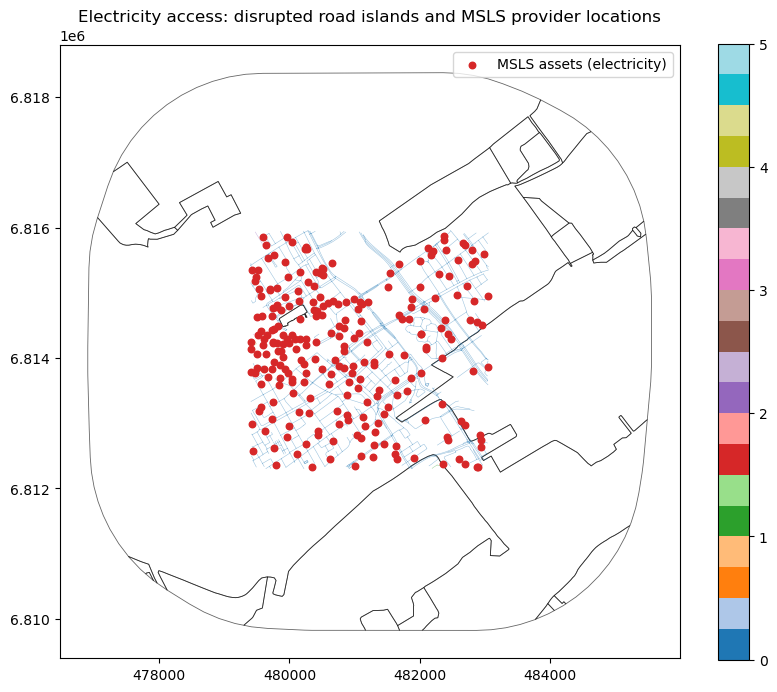

In [4]:
# 1) Build disrupted road-island geometries for visual context
hazard_graph_path = config['hazard_dir'].parent / 'static' / 'output_graph' / 'base_graph_hazard_editted.p'
islands_gdf = compute_island_geodataframe_from_graph(
    graph_pickle_path=str(hazard_graph_path),
    hazard_threshold=simulation_params['flood_threshold'],
    hazard_column='EV0_ma',
    buffer_distance=2.5,
    verbose=False,
)

# 2) Build societal-access inputs — MSLS is the non-redundant electricity layer
service_nodes_gdf = (
    gdf_assets.loc[gdf_assets['type'].eq('msls'), ['type', 'geometry']]
    .copy()
    .to_crs(islands_gdf.crs)
)

study_area = gpd.read_file(study_area_path, driver='GeoJSON').to_crs("EPSG:28992")

buffer_distance_meters = 200
population_buffer = study_area.buffer(buffer_distance_meters)
population_buffer.set_crs("EPSG:28992")

# MSLS-only Voronoi layer (also reused by the legacy population-impact workflow below)
print("Creating Voronoi polygons for MSLS service areas...")
msls_voronoi_gdf = create_voronoi_for_asset_type(
    gdf_assets,
    'msls',
    boundary=study_area.geometry.unary_union,
)


# Keep legacy variable name used later in the notebook
voronoi_polygons_by_type = {'msls': msls_voronoi_gdf}

population_data = gpd.read_file(
    population_data_path,
    driver="GPKG",
    bbox=tuple(msls_voronoi_gdf.total_bounds),
).to_crs("EPSG:28992")

population_data = population_data[
    population_data["aantal_inwoners"] > 0
].dropna(subset=["geometry"])
pop_cols = ['aantal_inwoners', 'aantal_inwoners_65_jaar_en_ouder', 'aantal_inwoners_0_tot_15_jaar']
population_for_societal = population_data[pop_cols + ['geometry']].copy().to_crs(islands_gdf.crs)
population_for_societal = population_for_societal.reset_index(drop=True)
population_for_societal['cell_id'] = population_for_societal.index.astype(str)

road_state_key = 'hazard_EV0_ma_threshold_{:.2f}'.format(simulation_params['flood_threshold'])
societal_allocation_cache = caches.get('societal_allocation_cache') or {}
allocations, alloc_key, cache_updated = get_or_build_allocation(
    societal_allocation_cache,
    population_for_societal,
    'cell_id',
    islands_gdf[['island_id', 'geometry']],
    road_state_key=road_state_key,
)
if cache_updated:
    caches['societal_allocation_cache'] = societal_allocation_cache
    save_simulation_caches({'societal_allocation_cache': societal_allocation_cache},
                           config['interim_dir'], config['hazard_dir'])
    print(f"Allocation built and cached (key: {alloc_key})")
else:
    print(f"Reusing cached allocation (key: {alloc_key})")

allocation_with_population = apply_population_to_allocations(
    allocation_df=allocations,
    pop_grid_gdf=population_for_societal,
    cell_id_column='cell_id',
)

# 3) Visualise network islands + MSLS assets + peilgebied contours
fig, ax = plt.subplots(figsize=(10, 8))

peilgebied_3857 = gpd.read_file(root_dir / 'data' / 'utilities' / 'Peilgebieden_3857.shp').to_crs('EPSG:3857')
islands_3857 = islands_gdf.to_crs('EPSG:3857')
services_3857 = service_nodes_gdf.to_crs('EPSG:3857')

focus_geom = gpd.GeoDataFrame(geometry=[services_3857.unary_union.convex_hull.buffer(2500)], crs='EPSG:3857')
peilgebied_focus = gpd.clip(peilgebied_3857, focus_geom)
if peilgebied_focus.empty:
    peilgebied_focus = peilgebied_3857

peilgebied_focus.boundary.plot(ax=ax, color='black', linewidth=0.6, alpha=0.6, zorder=1)
islands_3857.plot(ax=ax, column='island_id', cmap='tab20', linewidth=0.4, alpha=0.45, legend=True, zorder=2)
services_3857.centroid.plot(ax=ax, color='#d62728', markersize=22, label='MSLS assets (electricity)', zorder=3)

ax.set_title('Electricity access: disrupted road islands and MSLS provider locations')
ax.legend(loc='upper right')
plt.show()


In [5]:

# study_area and population_buffer are already set in the societal-access cell above

# Load and prepare population data for legacy population-impact workflow
# msls_voronoi_gdf was built in the societal-access cell; reuse it here.
voronoi_gdf = msls_voronoi_gdf
if 'voronoi_polygons_by_type' not in locals():
    voronoi_polygons_by_type = {'msls': voronoi_gdf}


print("Loading population data...")
population_data = gpd.read_file(
    population_data_path,
    driver='GPKG',
    bbox=tuple(voronoi_gdf.total_bounds)
).to_crs("EPSG:28992")

# Filter out zero population and invalid geometries
population_data = population_data[
    (population_data['aantal_inwoners'] > 0) & 
    (~population_data.geometry.isna())
].dropna(subset=['geometry'])

# Clip to study area
population_study_area = gpd.clip(population_data, population_buffer)
pop_cols_to_keep = ['aantal_inwoners', 'aantal_inwoners_65_jaar_en_ouder', 'aantal_inwoners_0_tot_15_jaar']
population_above_0 = population_study_area[pop_cols_to_keep + ['geometry']].set_crs("EPSG:28992")

# Make all negative counts 0
for col in pop_cols_to_keep:
    population_above_0[col] = population_above_0[col].clip(lower=0)

# Prepare population impact mapping
print("Preparing population impact data...")
asset_population_map = prepare_population_impact_data(
    population_data=population_above_0,
    voronoi_gdf=voronoi_gdf
)
print(f"Population data prepared for {len(asset_population_map)} assets")

voronoi_gdf['pop_map'] = [asset_population_map[x] for x in voronoi_gdf['asset_id']]


Loading population data...


c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


Preparing population impact data...
Population assignment: 221/229 polygons with impact values
Total assigned population: 41969
Population data prepared for 229 assets


In [6]:
import pickle
# Try to load pre-computed asset_to_lu
if asset_to_lu_cache_path.exists():
    print(f"Loading asset_to_lu from cache: {asset_to_lu_cache_path}")
    with open(asset_to_lu_cache_path, 'rb') as f:
        asset_to_lu = pickle.load(f)
    print(f"Loaded asset_to_lu for {len(asset_to_lu)} assets from cache")

    asset_land_use_map = {
        aid: {lu_type: area for lu_type, area, voll_rate in lu_entries}
        for aid, lu_entries in asset_to_lu.items()
    }
    
else:
    print("Computing asset_to_lu from scratch...")
       
    # Load land use data
    land_use_data = gpd.read_file(land_use_path, driver='GPKG')
    
    # Calculate VOLL rates (populates VOLL_PER_SQM)
    consumption_per_sqm, voll_per_sqm = update_voll_rates(land_use_data)
    print(f"VOLL rates calculated for {len(voll_per_sqm)} categories")
    
    # Compute asset-land use intersections (the expensive operation)
    asset_land_use_map = prepare_land_use_impact_data(
        land_use_data, 
        voronoi_gdf=voronoi_polygons_by_type['msls']
    )
    print(f"Computed intersections for {len(asset_land_use_map)} assets")
    
    # Build asset_to_lu with VOLL rates included
    asset_to_lu = {}
    for aid, lu_dict in asset_land_use_map.items():
        asset_to_lu[aid] = [(lu_type, area, voll_per_sqm[lu_type]) 
                             for lu_type, area in lu_dict.items() 
                             if lu_type in voll_per_sqm]
    
    # Cache the complete lookup
    with open(asset_to_lu_cache_path, 'wb') as f:
        pickle.dump(asset_to_lu, f)
    print(f"Saved asset_to_lu to cache: {asset_to_lu_cache_path}")

# Output
print(f"\nasset_to_lu ready with {len(asset_to_lu)} assets")


Computing asset_to_lu from scratch...
Consumption per square meter by land use [MWh/h/m²]:
  commercial: 0.0023797518
  industrial: 0.0066238837
  public_sector: 0.0024542763
  transport: 0.0010109956
  residential: 0.0035054641
  other: 0.0000023999

VOLL per square meter by land use [€/h/m²]:
  commercial: 202.115201
  industrial: 511.113373
  public_sector: 246.235459
  transport: 107.078586
  residential: 121.293896
  other: 0.000002
VOLL rates calculated for 6 categories
Consumption per square meter by land use [MWh/h/m²]:
  commercial: 0.0023797518
  industrial: 0.0066238837
  public_sector: 0.0024542763
  transport: 0.0010109956
  residential: 0.0035054641
  other: 0.0000023999

VOLL per square meter by land use [€/h/m²]:
  commercial: 202.115201
  industrial: 511.113373
  public_sector: 246.235459
  transport: 107.078586
  residential: 121.293896
  other: 0.000002


c:\Users\peregrin\AppData\Local\miniconda3\envs\miraca_template\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


Computed intersections for 229 assets
Saved asset_to_lu to cache: c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\CBS_Publicatiebestand_BBG2017_v1_sample_asset_to_lu.pkl

asset_to_lu ready with 229 assets


In [7]:
from ema_workbench import Model, RealParameter, IntegerParameter, Constant, TimeSeriesOutcome, SequentialEvaluator, Samplers, ema_logging, Policy

ema_logging.log_to_stderr(ema_logging.INFO)

hazard_maps = load_hazard_maps(config['hazard_dir'], max_days=None)  


# Load caches
caches = load_simulation_caches(config['interim_dir'], config['hazard_dir'])
print(f"Loaded caches: {[k for k in caches.keys() if caches[k] is not None]}")

max_days = None
execution_id = int(time.time())

# Set up EMA model
model = Model('ElectricitySimulation', function=simulate_asset_damage_recovery_access_breakdown_ema)

model.uncertainties = [
    IntegerParameter('number_repair_crews', 1, 5),
    RealParameter('fragility_param_k', 5.0, 7.5)
]

keep_3d_vars = []  # No per-asset arrays
keep_2d_vars = ['flooded', 'operational', 'damage_ratio', 'repair_time']  # Aggregated

# Build societal-access configuration (MSLS = electricity, non-redundant layer)

societal_access_config = {
    'pop_grid_gdf': population_for_societal,
    'cell_id_column': 'cell_id',
    'pop_group_columns': {
        'total': 'aantal_inwoners',
        'elderly': 'aantal_inwoners_65_jaar_en_ouder',
        'children': 'aantal_inwoners_0_tot_15_jaar',
    },
    'taxonomy': {'msls': 'electricity', 'hospital': 'hospital'},
    'asset_type_column': 'type',
    'all_functions': ['electricity', 'hospital'],
    'allocation_cache': caches.get('societal_allocation_cache') or {},
    'shared_realized_state_cache_config': shared_cache_cfg,
    'cache_telemetry': cache_telemetry,
}

model.constants = [
    Constant('flood_threshold', 0.2),
    Constant('gdf_assets', gdf_assets),
    Constant('hazard_maps', hazard_maps[:max_days]),
    Constant('recovery_parameters', config['recovery_parameters']),
    Constant('root_dir', config['root_dir']),
    Constant('verbose', False),
    Constant('timestep_output', True),
    Constant('execution_id', execution_id),
    Constant('config', config),
    Constant('major_timestep', 24),
    # Cache parameters
    Constant('accessibility_cache', caches.get('accessibility_cache')),
    Constant('hazard_extraction_cache', caches.get('hazard_extraction_cache')),
    Constant('overlap_cache', caches.get('overlap_cache')),
    Constant('island_cache', caches.get('island_cache')),
    # Impact data
    Constant('asset_population_map', asset_population_map),
    Constant('asset_to_lu', asset_to_lu),
    # Societal access (MSLS electricity)
    Constant('societal_access_config', societal_access_config),
    # Dimensionality control
    Constant('keep_3d_vars', keep_3d_vars),
    Constant('keep_2d_vars', keep_2d_vars),
]

# Build outcomes list
outcomes_list = []

# Add 3D outcomes (none in this case)
for var in keep_3d_vars:
    outcomes_list.append(TimeSeriesOutcome(var))

# Add 2D outcomes (aggregated across assets)
for var in keep_2d_vars:
    outcomes_list.append(TimeSeriesOutcome(var))

# Build societal outcomes from configuration
societal_outcome_names = list_societal_metric_names(
    all_functions=societal_access_config['all_functions'],
    pop_group_columns=societal_access_config['pop_group_columns'],
    reference_group=societal_access_config.get('reference_group', 'total'),
)

# Add mandatory 1D outcomes (always present)
outcomes_list.extend([
    TimeSeriesOutcome('timesteps'),
    # Population impact outcomes
    TimeSeriesOutcome('affected_population'),
    TimeSeriesOutcome('served_population'),
    TimeSeriesOutcome('affected_population_ratio'),
    # Monetary impacts
    TimeSeriesOutcome('monetary_impact_total'),
    TimeSeriesOutcome('monetary_impact_residential'),
    TimeSeriesOutcome('monetary_impact_commercial'),
    TimeSeriesOutcome('monetary_impact_industrial'),
    TimeSeriesOutcome('monetary_impact_transport'),
    TimeSeriesOutcome('monetary_impact_public_sector'),
])
outcomes_list.extend(TimeSeriesOutcome(name) for name in societal_outcome_names)

model.outcomes = outcomes_list

# Smoke test first: deterministic islands and one baseline case to verify output wiring
smoke_policy = [
    Policy('baseline_smoke', repair_crew_assignment_method='monetary impacts islands')
]

with SequentialEvaluator(model) as evaluator:
    smoke_experiments, smoke_outcomes = evaluator.perform_experiments(
        scenarios=1,
        policies=smoke_policy,
        uncertainty_sampling=Samplers.LHS,
    )

missing_smoke_outcomes = [name for name in societal_outcome_names if name not in smoke_outcomes]
none_smoke_outcomes = [name for name in societal_outcome_names if smoke_outcomes.get(name) is None]

if missing_smoke_outcomes or none_smoke_outcomes:
    raise ValueError(
        'Societal outcome wiring failed in smoke test. '
        f'Missing: {missing_smoke_outcomes}; None: {none_smoke_outcomes}'
    )

print(f"Smoke test passed with {len(smoke_experiments)} run.")

# Set up policies for full experiment batch
l1_pumping_area = root_dir / 'data' / 'test_samples' / 'adaptation' / 'L1_peilgeb_policies_separate' / 'policy_L1_area_population_top30_red_0.4.geojson'
l2_asset_barriers = root_dir / 'data' / 'test_samples' / 'adaptation' / 'L2_asset_barriers' / 'mon_subs_top30_1.0m.geojson'

policies = [
    Policy('population_impacts_policy', repair_crew_assignment_method='population impacts islands'),
    Policy('monetary_impacts_policy', repair_crew_assignment_method='monetary impacts islands'),
    Policy('lowest_repair_time_islands_policy', repair_crew_assignment_method='lowest repair time islands'),
    Policy('highest_repair_time_islands_policy', repair_crew_assignment_method='highest repair time islands'),
    Policy('baseline', repair_crew_assignment_method='monetary impacts islands'),
    Policy(
        'L1_area_pumping + monetary',
        repair_crew_assignment_method='monetary impacts islands',
        l1_area_geojson=str(l1_pumping_area),
    ),
    Policy(
        'L2_asset_protection + monetary',
        repair_crew_assignment_method='monetary impacts islands',
        l2_asset_geojson=str(l2_asset_barriers),
    ),
    Policy(
        'L1_and_L2_combined + monetary',
        repair_crew_assignment_method='monetary impacts islands',
        l1_area_geojson=str(l1_pumping_area),
        l2_asset_geojson=str(l2_asset_barriers),
    ),
]

# with SequentialEvaluator(model) as evaluator:
#     experiments, outcomes = evaluator.perform_experiments(
#         scenarios=10,
#         policies=policies,
#         uncertainty_sampling=Samplers.LHS,
#     )

# experiments_df = pd.DataFrame(experiments)
# print(f"\nCompleted all experiments with execution id {execution_id}. Total runs: {len(experiments)}")


[MainProcess/INFO] performing 1 scenarios * 1 policies * 1 model(s) = 1 experiments


Found 10 hazard map files
Loading simulation caches...
No accessibility cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\accessibility_cache_test_hazard_timesteps.pkl
No hazard extraction cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\hazard_extraction_cache_test_hazard_timesteps.pkl
No island cache found at c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\island_cache_test_hazard_timesteps.pkl
Loaded societal allocation cache: 1 entries from c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\societal_allocation_cache_test_hazard_timesteps.pkl
Loaded caches: ['accessibility_cache', 'hazard_extraction_cache', 'overlap_cache', 'island_cache', 'societal_allocation_cache']


  0%|                                                    | 0/1 [00:00<?, ?it/s][MainProcess/INFO] performing experiments sequentially


Identified 14 boundary assets out of 245 total assets.
Extracting hazard values using method: max
Saved hazard extraction cache: 1 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\hazard_extraction_cache_test_hazard_timesteps.pkl
Cached hazard extraction results for map 0 from Frag_timesteps_test0.tif
Extracting hazard values using method: max
Saved hazard extraction cache: 2 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\hazard_extraction_cache_test_hazard_timesteps.pkl
Cached hazard extraction results for map 1 from Frag_timesteps_test1.tif
Saved overlap cache: 1 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Extracting hazard values using method: max
Saved hazard extraction cache: 3 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\hazard_extraction_cache_test_hazard_timesteps.pkl
Cached hazard extraction r

100%|████████████████████████████████████████████| 1/1 [00:14<00:00, 14.71s/it]
[MainProcess/INFO] experiments finished


Smoke test passed with 1 run.


In [8]:
def run_ema(evaluator_cls, evaluator_kwargs):
    start = time.time()
    with evaluator_cls(model, **evaluator_kwargs) as evaluator:
        experiments, outcomes = evaluator.perform_experiments(
            scenarios=10,
            policies=policies,
            uncertainty_sampling=Samplers.LHS,
        )
    elapsed = time.time() - start
    return experiments, outcomes, elapsed

# sequential baseline
exp_seq, out_seq, t_seq = run_ema(SequentialEvaluator, {})

# multiprocessing / distributed-style run
exp_mp, out_mp, t_mp = run_ema(MultiprocessingEvaluator, {'n_processes': 4})

print('Sequential seconds:', t_seq)
print('Multiprocessing seconds:', t_mp)
print('Speedup:', (t_seq / t_mp) if t_mp > 0 else float('nan'))
print('Cache telemetry:', cache_telemetry)


[MainProcess/INFO] performing 10 scenarios * 8 policies * 1 model(s) = 80 experiments
 62%|██████████████████████████▎               | 50/80 [00:24<00:13,  2.22it/s]

Identified 14 boundary assets out of 245 total assets.
Saved overlap cache: 10 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 11 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 12 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 13 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 14 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 15 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 16 entries to c:\repos\powerpath\powerpath

 75%|███████████████████████████████▌          | 60/80 [00:36<00:11,  1.81it/s]

Identified 14 boundary assets out of 245 total assets.
Saved overlap cache: 19 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 20 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 21 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 22 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 23 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 24 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 25 entries to c:\repos\powerpath\powerpath

 88%|████████████████████████████████████▊     | 70/80 [00:47<00:05,  1.78it/s]

Identified 14 boundary assets out of 245 total assets.
Saved overlap cache: 28 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 29 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 30 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 31 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 32 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 33 entries to c:\repos\powerpath\powerpath\data\interim\interim_test_hazard_timesteps\overlap_cache_test_hazard_timesteps.pkl
Saved overlap cache: 34 entries to c:\repos\powerpath\powerpath

100%|██████████████████████████████████████████| 80/80 [00:59<00:00,  1.34it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] pool started with 4 workers
[MainProcess/INFO] performing 10 scenarios * 8 policies * 1 model(s) = 80 experiments
100%|██████████████████████████████████████████| 80/80 [00:11<00:00,  7.04it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


Sequential seconds: 59.83525538444519
Multiprocessing seconds: 30.25500249862671
Speedup: 1.977697915812803
Cache telemetry: {'local_lookups': 19440, 'local_hits': 18036, 'local_misses': 1404, 'shared_lookups': 1404, 'shared_hits': 1313, 'shared_misses': 91, 'shared_writes': 91, 'shared_write_conflicts': 0, 'shared_errors': 0, 'shared_backend_lookups': 15, 'shared_backend_hits': 15, 'shared_backend_misses': 0, 'shared_backend_writes': 0, 'shared_backend_write_conflicts': 0, 'shared_backend_lock_retries': 0, 'shared_backend_errors': 0}


In [9]:
telemetry_df = pd.DataFrame([cache_telemetry]).T.reset_index()
telemetry_df.columns = ['metric', 'value']
telemetry_df


,metric,value
0,local_lookups,19440
1,local_hits,18036
2,local_misses,1404
3,shared_lookups,1404
4,shared_hits,1313
5,shared_misses,91
6,shared_writes,91
7,shared_write_conflicts,0
8,shared_errors,0
9,shared_backend_lookups,15
